# [LAB 07] 9. 상관분석의 이해
## #01. 준비작업
### 1. 라이브러리 참조

In [14]:
from hossam import load_data
from helpers import *
import numpy as np
from scipy.stats import pearsonr, spearmanr

### 2. 데이터 가져오기

In [15]:
origin = load_data('language_math_scores')
origin.head()

📚 어느 학급의 언어영역과 수리영역 점수를 기록한 가상의 데이터 셋


,언어영역,수리영역
0,66,66
1,58,70
2,73,74
3,52,58
4,72,79


## #02. 시각화를 통한 상관정도 확인
### 1. 산점도 그래프 시각화

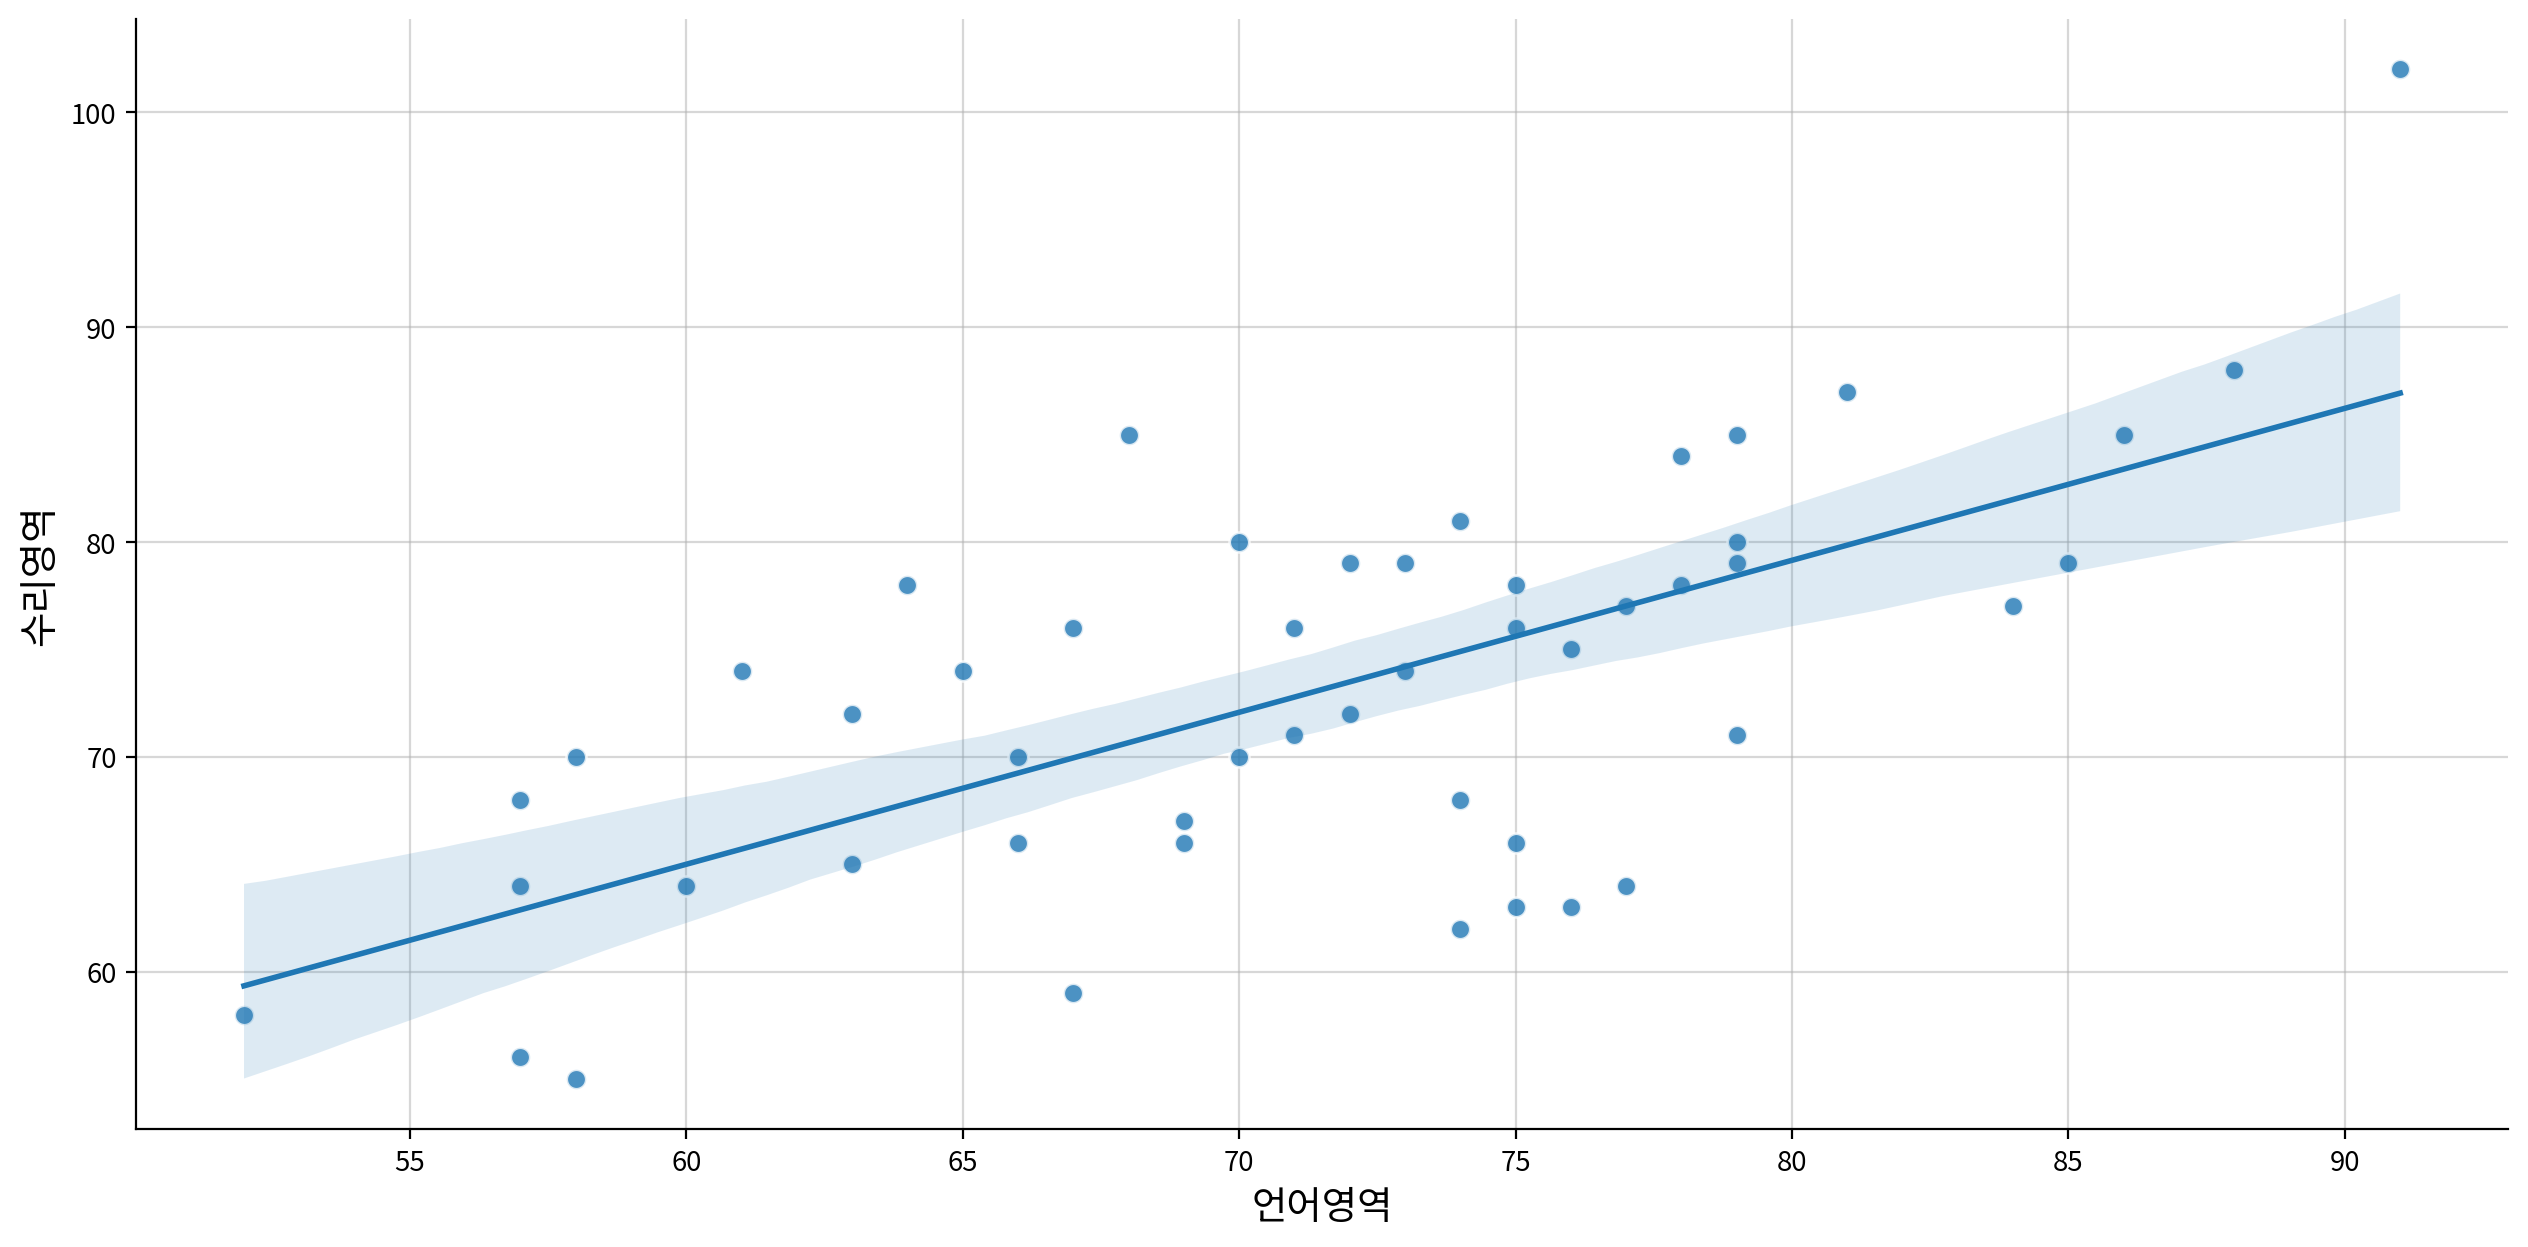

In [16]:
my_plot. lmplot(origin, x='언어영역', y='수리영역')

- 인사이트 
    - 언어영역 점수가 높을 수록 수리영역 점수도 함께 높아지는 경향이 있음
    - 두 변수는 대체로 직선적인 관계를 보임
    - 다만 점들이 넓게 퍼져 있어 관계가 아주 강하다고 보긴 어려움
    - 일부 벗어난 점도 보여서 해석할 때 같이 봐야 함

## #03. 공분산
### 1. 공분산 행렬 구하기
- 파이썬 해서는 numpy패키지의 cov() 함수를 사용하여 공분산 값을 구할 수 있다.
    - 2차원 배열이 리턴되는데 이중에서 공분산 값은 0행 1열 혹은 1행 0열의 값이다.
- 공분산은 상관관계의 상승 혹은 하강하는 경향을 이해할 수 있으나 2개 변수의 측정 단위의 크기에 따라 값이 달라지므로 절대적 정도를 파악하기에는 한계가 있다.
    - 결과값이 양수면 정비례, 음수변 반비례

In [17]:
c= np.cov(origin['언어영역'], origin['수리영역'])
c

array([[76.86693878, 54.39020408],
       [54.39020408, 85.57714286]])

## #04. 상관분선
### 1. 피어슨 상관계수

In [18]:
pearson_r, pearson_p = pearsonr(origin['언어영역'], origin['수리영역'])
print(f'Pearson correlation coefficiesnt: {pearson_r:.4f}, p-value: {pearson_p:.4f}')

Pearson correlation coefficiesnt: 0.6706, p-value: 0.0000


- 피어슨 상관계수 0.6707으로, 두 변수는 양의 상관관계가 있음
- p-value가 0.000이라 통계적으로 유의함
- 상관정도는 위 강도 기준표에 따라 중간 수준임(|r|이 0.7을 넘지 않음)

### 2. 스피어만 상관계수

In [19]:
spearman_r, spearman_p = spearmanr(origin['언어영역'], origin['수리영역'])
print(f'Pearson correlation coefficiesnt: {spearman_r:.4f}, p-value: {spearman_p:.4f}')

Pearson correlation coefficiesnt: 0.5991, p-value: 0.0000


- 스피어만 상관계수 0.5991로 두 변수는 양의 상관관계가 있음
- p-value는 0.0000이라 통계적으로 유의함
- 순위 기준으로도 중간 정도의 관련성이 보임

### 3. 상관행렬
- 여러 번수들간의 상관계수를 한눈에 볼 수 있도록 정리한 표
    - 행과 열에 같은 변수들이 배치
    - 대각선 값은 항상 1(자기 자신과의 상관 계수)
    - 대칭행렬(A와 B의 상관계수 = B와 A의 상관계수)

In [20]:
# 분석 대상 변수명 정의 (이후 셀에서 공통으로 사용)
xname = '언어영역'
yname = '수리영역'

#method = 'pearson' or 'spearman'
corr_matrix = origin[[xname, yname]].corr(method='pearson')
corr_matrix

,언어영역,수리영역
언어영역,1.000,0.671
수리영역,0.671,1.000


### 4. 상관계수 히트맵
- 상관행렬을 시각화 한 그래프

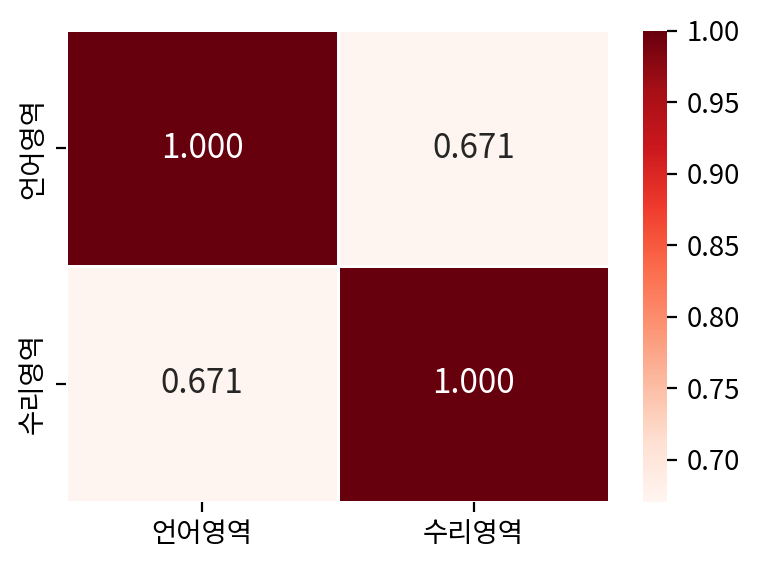

In [21]:
my_plot.heatmap(corr_matrix, width=400, height=300, palette='Reds', annot=True, fmt=".3f")

### 5. 상관행렬에 직접 배경색상 적용

In [22]:
corr_matrix.style.background_gradient(cmap='Reds')

,언어영역,수리영역
언어영역,1.000000,0.670613
수리영역,0.670613,1.000000
